# Embeddings — How Machines Understand Meaning

In [1]:
# If you are running this on Google Colab, uncomment and run the line below first.
!pip install -q sentence-transformers scikit-learn matplotlib pandas


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## The problem with token IDs

In the Previous section - Tokenization, we saw how text gets converted into token IDs — numbers like 15339, 389, 264. These numbers are just labels, like barcodes. The model has no idea that "king" and "queen" are related, or that "car" and "vehicle" mean similar things.

For a model to actually understand meaning, we need something much richer than a label.

That something is **embeddings**.

An embedding is a list of numbers (called a **vector**) that represents the meaning of a word or sentence. The key property is simple: **similar meanings produce similar vectors**.

Imagine placing every sentence on a giant map. Sentences that mean similar things land near each other. Sentences about completely different topics land far apart. That is the embedding space.

This is what makes it possible to search for "best place to get a burger" and get results about "fast food joints" — even though those exact words never appeared in the documents you are searching.

## Generating your first embeddings

We will use `sentence-transformers`, a library that makes it easy to generate high-quality sentence embeddings.

The model `all-MiniLM-L6-v2` is a small, fast model that produces 384-dimensional embeddings. It is a good starting point for learning and building prototypes.

In [2]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

sentences = [
    "I love spicy food",
    "Biryani is my favourite dish",
    "Indian cuisine has many vegetarian options",
    "Football is a popular sport worldwide",
    "The match ended in a draw",
]

embeddings = model.encode(sentences)

print(f"Number of sentences : {embeddings.shape[0]}")
print(f"Embedding dimensions: {embeddings.shape[1]}")
print(f"\nFirst sentence  : '{sentences[0]}'")
print(f"Its embedding (first 8 numbers): {embeddings[0][:8].round(4)}")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 20235.76it/s]


Number of sentences : 5
Embedding dimensions: 384

First sentence  : 'I love spicy food'
Its embedding (first 8 numbers): [-0.0461 -0.0945 -0.0188  0.0797 -0.032   0.0186  0.0352  0.0417]


## What are those 384 numbers?

Each sentence produced a list of 384 numbers. But what do they actually represent?

Each number captures a different learned aspect of meaning — things like topic, sentiment, formality, or the relationship between concepts. No single number has an obvious human-readable label, because these features are discovered automatically by the model during training.

A helpful analogy: think about how colours work on a screen. Every colour is described by just three numbers — R, G, B. Each captures a different dimension of the colour. Combine them and you can represent any colour.

Embeddings do the same thing for meaning, but with 384 dimensions (for all-MiniLM-L6-v2 embedding) instead of 3.

The actual values of the numbers matter less than their **relationships**. Two sentences with similar meanings will produce vectors that point in roughly the same direction in that 384-dimensional space. That is what allows us to measure how similar two pieces of text are.

## Measuring similarity between sentences

To compare two embeddings, we use **cosine similarity**. It measures the angle between two vectors:

- A score close to **1.0** means the two sentences point in the same direction — similar meaning.
- A score close to **0.0** means they are pointing in different directions — unrelated.

Let's compute a similarity matrix for all five sentences and display it as a readable table.

In [4]:
import pandas as pd
from sentence_transformers import util

similarity_matrix = util.cos_sim(embeddings, embeddings).numpy()

# Shorten labels so the table fits nicely
labels = [s[:28] + "..." if len(s) > 28 else s for s in sentences]
df = pd.DataFrame(similarity_matrix, index=labels, columns=labels).round(2)

print("Cosine Similarity Matrix")
print("(1.0 = identical meaning, 0.0 = completely unrelated)\n")
print(df.to_string())
print()
print("Notice: food-related sentences score higher with each other,")
print("and sports-related sentences score higher with each other.")

Cosine Similarity Matrix
(1.0 = identical meaning, 0.0 = completely unrelated)

                                 I love spicy food  Biryani is my favourite dish  Indian cuisine has many vege...  Football is a popular sport ...  The match ended in a draw
I love spicy food                             1.00                          0.45                             0.37                             0.13                      -0.02
Biryani is my favourite dish                  0.45                          1.00                             0.44                             0.09                      -0.00
Indian cuisine has many vege...               0.37                          0.44                             1.00                             0.03                      -0.09
Football is a popular sport ...               0.13                          0.09                             0.03                             1.00                       0.11
The match ended in a draw                    -0.02

## Seeing the embedding space in 2D

384 dimensions is impossible to visualise directly, but we can project it down to 2 dimensions using **PCA** (Principal Component Analysis). This loses some detail, but it gives us a rough map of how the sentences are arranged in meaning-space.

Sentences that cluster together in the plot are the ones the model considers semantically similar.

Matplotlib is building the font cache; this may take a moment.


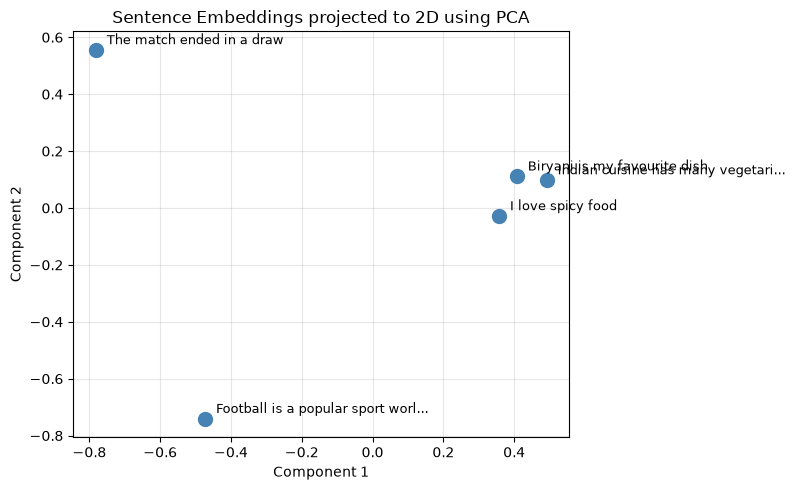

The food-related sentences should cluster on one side,
and the sports-related sentences on the other.


In [5]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

plt.figure(figsize=(8, 5))
plt.scatter(reduced[:, 0], reduced[:, 1], color="steelblue", s=100, zorder=2)

for i, sentence in enumerate(sentences):
    label = sentence if len(sentence) <= 35 else sentence[:32] + "..."
    plt.annotate(label, (reduced[i, 0], reduced[i, 1]),
                 textcoords="offset points", xytext=(8, 4), fontsize=9)

plt.title("Sentence Embeddings projected to 2D using PCA")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("The food-related sentences should cluster on one side,")
print("and the sports-related sentences on the other.")

## Semantic search

The real power of embeddings shows up in search. Instead of matching exact keywords, we embed the query and find the sentences that are closest to it in meaning.

This means you can search for "what food would you recommend" and find results about biryani and Indian cuisine — even though the word "recommend" never appears in those sentences.

In [6]:
from sentence_transformers import util

query = "what food would you recommend"
query_embedding = model.encode(query)

scores = util.cos_sim(query_embedding, embeddings)[0]
results = sorted(zip(sentences, scores), key=lambda x: x[1], reverse=True)

print(f"Query: '{query}'\n")
print(f"{'Score':<8}  Sentence")
print("-" * 55)
for sentence, score in results:
    print(f"{score:.4f}    {sentence}")

print()
print("The food-related sentences rank higher than the sports ones,")
print("even though the query shares no exact words with them.")

Query: 'what food would you recommend'

Score     Sentence
-------------------------------------------------------
0.4413    Indian cuisine has many vegetarian options
0.4409    Biryani is my favourite dish
0.4368    I love spicy food
0.0944    Football is a popular sport worldwide
-0.0591    The match ended in a draw

The food-related sentences rank higher than the sports ones,
even though the query shares no exact words with them.


## Choosing an embedding model

`all-MiniLM-L6-v2` is great for learning, but it is not the only option. Here is a quick comparison of common choices:

| Model | Dimensions | Speed | Best for |
|---|---|---|---|
| `all-MiniLM-L6-v2` | 384 | Very fast | Learning, prototyping, lightweight apps |
| `all-mpnet-base-v2` | 768 | Medium | Better quality, general purpose |
| `text-embedding-3-small` (OpenAI) | 1536 | API call | Production apps, multilingual |
| `text-embedding-3-large` (OpenAI) | 3072 | API call | Best quality, when accuracy matters most |

More dimensions generally means more nuance captured, but also more memory and slower comparisons. For most projects, start with a smaller model and only upgrade if the quality is not good enough.

## Key takeaways

- Embeddings convert text into vectors — lists of numbers that capture meaning.
- Similar meanings produce similar vectors. Distance in embedding space reflects difference in meaning.
- **Cosine similarity** measures how close two embeddings are — the main tool for comparing them.
- We can project embeddings to 2D with PCA to visualise how sentences relate to each other.
- **Semantic search** uses embeddings to find relevant content by meaning, not by matching keywords.
- Different embedding models trade off size, speed, and quality. Start small and upgrade if needed.

---

This is the foundation of RAG (Retrieval-Augmented Generation). When a RAG system finds relevant documents for a question, it is doing exactly what you did here — comparing embeddings.

**Useful tools to explore embedding spaces interactively:**
- https://projector.tensorflow.org/
- http://vectors.nlpl.eu/explore/embeddings/en/#